In [1]:
import joblib
import os
import matplotlib.pyplot as plt
import numpy as np
import config

from sklearn.metrics import (
    roc_auc_score, roc_curve,
    confusion_matrix, precision_score, recall_score
)

In [2]:
# Path to your saved artifacts
output_dir = "../models/lasso_bootstrapped_selectkbest_grid_search"

# Load everything
best_model = joblib.load(os.path.join(output_dir, "lasso_model.joblib"))
grid_search = joblib.load(os.path.join(output_dir, "lasso_gridsearch.joblib"))
X_train = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "X_train.joblib"))
y_train = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "y_train.joblib"))
X_val = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "X_val.joblib"))
y_val = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "y_val.joblib"))
X_test = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "X_test.joblib"))
y_test = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "y_test.joblib"))

print("All artifacts loaded successfully!")
print("Best parameters:", grid_search.best_params_)


All artifacts loaded successfully!
Best parameters: {'clf__C': 1, 'select__k': 50, 'select__n_bootstrap': 50, 'select__threshold': 0.6}


In [3]:
# cv_results = grid_search.cv_results_

# mean_test_scores = cv_results['mean_test_score']
# std_test_scores = cv_results['std_test_score']
# params = cv_results['params']

# print("Grid Search Results:\n")
# for mean, std, param in zip(mean_test_scores, std_test_scores, params):
#     print(f"Parameters: {param}")
#     print(f"Mean AUC-ROC: {mean:.4f} ± {std:.4f}")
#     print("-" * 40)

cv_results = grid_search.cv_results_

mean_test_scores = cv_results['mean_test_score']
std_test_scores = cv_results['std_test_score']
params = cv_results['params']

print("Grid Search Results:\n")
for mean, std, param in zip(mean_test_scores, std_test_scores, params):
    print(f"Parameters: {param}")
    print(f"Mean AUC-ROC: {mean:.4f} ± {std:.4f}")
    print("-" * 40)

# Print best combination
print("\nBest Model Summary:")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Mean AUC-ROC: {grid_search.best_score_:.4f}")


Grid Search Results:

Parameters: {'clf__C': 0.01, 'select__k': 25, 'select__n_bootstrap': 20, 'select__threshold': 0.2}
Mean AUC-ROC: 0.5000 ± 0.0000
----------------------------------------
Parameters: {'clf__C': 0.01, 'select__k': 25, 'select__n_bootstrap': 20, 'select__threshold': 0.3}
Mean AUC-ROC: 0.5000 ± 0.0000
----------------------------------------
Parameters: {'clf__C': 0.01, 'select__k': 25, 'select__n_bootstrap': 20, 'select__threshold': 0.4}
Mean AUC-ROC: 0.5000 ± 0.0000
----------------------------------------
Parameters: {'clf__C': 0.01, 'select__k': 25, 'select__n_bootstrap': 20, 'select__threshold': 0.5}
Mean AUC-ROC: 0.5000 ± 0.0000
----------------------------------------
Parameters: {'clf__C': 0.01, 'select__k': 25, 'select__n_bootstrap': 20, 'select__threshold': 0.6}
Mean AUC-ROC: 0.5000 ± 0.0000
----------------------------------------
Parameters: {'clf__C': 0.01, 'select__k': 25, 'select__n_bootstrap': 50, 'select__threshold': 0.2}
Mean AUC-ROC: 0.5000 ± 0.0000

Evaluating on Training Data
True Positives (TP): 50
False Positives (FP): 44
True Negatives (TN): 214
False Negatives (FN): 8
Precision: 0.532
Recall: 0.862
AUC-ROC: 0.9303


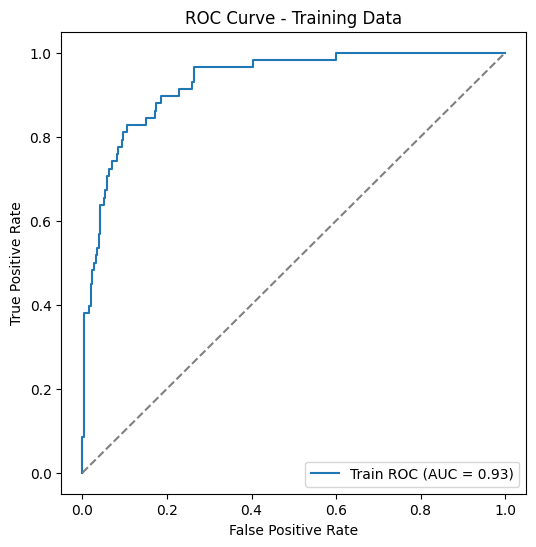

In [4]:
print("Evaluating on Training Data")

y_train_pred = best_model.predict(X_train)
if hasattr(best_model, "predict_proba"):
    y_scores_train = best_model.predict_proba(X_train)[:, 1]
elif hasattr(best_model, "decision_function"):
    y_scores_train = best_model.decision_function(X_train)
else:
    y_scores_train = y_train_pred

cm_train = confusion_matrix(y_train, y_train_pred)
tn, fp, fn, tp = cm_train.ravel()

precision = precision_score(y_train, y_train_pred)
recall = recall_score(y_train, y_train_pred)
roc_auc = roc_auc_score(y_train, y_scores_train)

print(f"True Positives (TP): {tp}")
print(f"False Positives (FP): {fp}")
print(f"True Negatives (TN): {tn}")
print(f"False Negatives (FN): {fn}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"AUC-ROC: {roc_auc:.4f}")

# ROC Curve
fpr, tpr, _ = roc_curve(y_train, y_scores_train)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"Train ROC (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Training Data")
plt.legend()
plt.show()


Evaluating on Validation Data
True Positives (TP): 7
False Positives (FP): 7
True Negatives (TN): 48
False Negatives (FN): 6
Precision: 0.500
Recall: 0.538
AUC-ROC: 0.6853


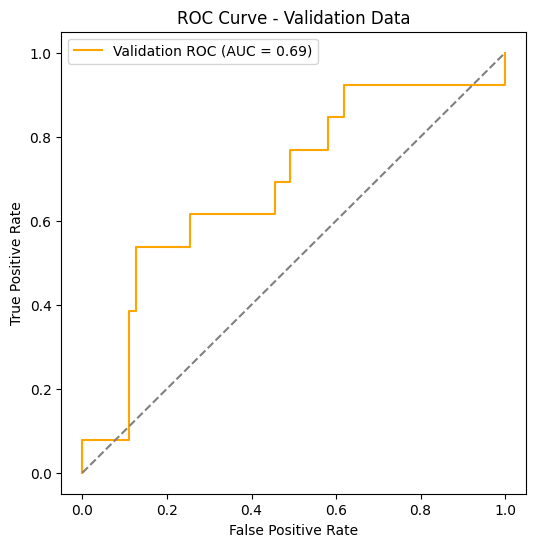

Using threshold = 0.535
True Positives (TP): 7
False Positives (FP): 7
True Negatives (TN): 48
False Negatives (FN): 6
Precision: 0.500
Recall: 0.538
AUC-ROC: 0.6853


In [13]:
print("Evaluating on Validation Data")

y_val_pred = best_model.predict(X_val)
if hasattr(best_model, "predict_proba"):
    y_scores_val = best_model.predict_proba(X_val)[:, 1]
elif hasattr(best_model, "decision_function"):
    y_scores_val = best_model.decision_function(X_val)
else:
    y_scores_val = y_val_pred

cm_val = confusion_matrix(y_val, y_val_pred)
tn, fp, fn, tp = cm_val.ravel()

precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
roc_auc = roc_auc_score(y_val, y_scores_val)

print(f"True Positives (TP): {tp}")
print(f"False Positives (FP): {fp}")
print(f"True Negatives (TN): {tn}")
print(f"False Negatives (FN): {fn}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"AUC-ROC: {roc_auc:.4f}")

# ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_scores_val)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"Validation ROC (AUC = {roc_auc:.2f})", color="orange")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Validation Data")
plt.legend()
plt.show()


# Compute predicted probabilities
if hasattr(best_model, "predict_proba"):
    y_scores_val = best_model.predict_proba(X_val)[:, 1]
elif hasattr(best_model, "decision_function"):
    y_scores_val = best_model.decision_function(X_val)
else:
    raise ValueError("Model does not support probability or decision scores.")

# Set a custom threshold
threshold = 0.535  # lower = more positive predictions
y_val_pred_custom = (y_scores_val >= threshold).astype(int)

# Evaluate
cm_val = confusion_matrix(y_val, y_val_pred_custom)
tn, fp, fn, tp = cm_val.ravel()

precision = precision_score(y_val, y_val_pred_custom)
recall = recall_score(y_val, y_val_pred_custom)
roc_auc = roc_auc_score(y_val, y_scores_val)

print(f"Using threshold = {threshold}")
print(f"True Positives (TP): {tp}")
print(f"False Positives (FP): {fp}")
print(f"True Negatives (TN): {tn}")
print(f"False Negatives (FN): {fn}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"AUC-ROC: {roc_auc:.4f}")


In [6]:
from sklearn.metrics import precision_recall_curve
import numpy as np

y_scores = best_model.predict_proba(X_val)[:, 1]
prec, rec, thresholds = precision_recall_curve(y_val, y_scores)
f1s = 2 * (prec * rec) / (prec + rec + 1e-10)
best_f1 = np.max(f1s)
best_thresh = thresholds[np.argmax(f1s)]

print(f"Max F1: {best_f1:.3f} at threshold {best_thresh:.3f}")


Max F1: 0.519 at threshold 0.535


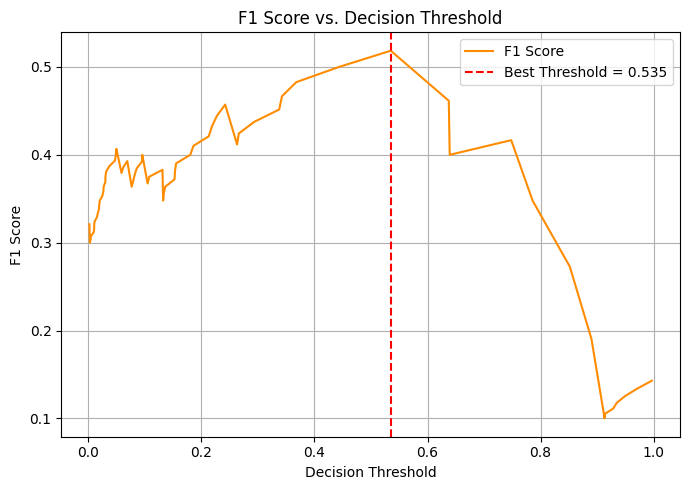

Best F1 = 0.519 at threshold = 0.535


In [7]:
# Make sure y_scores_val are probabilities or decision scores
# (you likely already have this part)
# y_scores_val = best_model.predict_proba(X_val)[:, 1]

# Compute precision, recall, thresholds
precisions, recalls, thresholds = precision_recall_curve(y_val, y_scores)

# Compute F1 for each threshold
f1s = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)

# Find best F1 and threshold
best_idx = np.argmax(f1s)
best_threshold = thresholds[best_idx]
best_f1 = f1s[best_idx]

# Plot
plt.figure(figsize=(7, 5))
plt.plot(thresholds, f1s[:-1], label="F1 Score", color="darkorange")
plt.axvline(best_threshold, color="red", linestyle="--", label=f"Best Threshold = {best_threshold:.3f}")
plt.title("F1 Score vs. Decision Threshold")
plt.xlabel("Decision Threshold")
plt.ylabel("F1 Score")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Best F1 = {best_f1:.3f} at threshold = {best_threshold:.3f}")


Evaluating on Test Data
AUC-ROC (Test): 0.6652


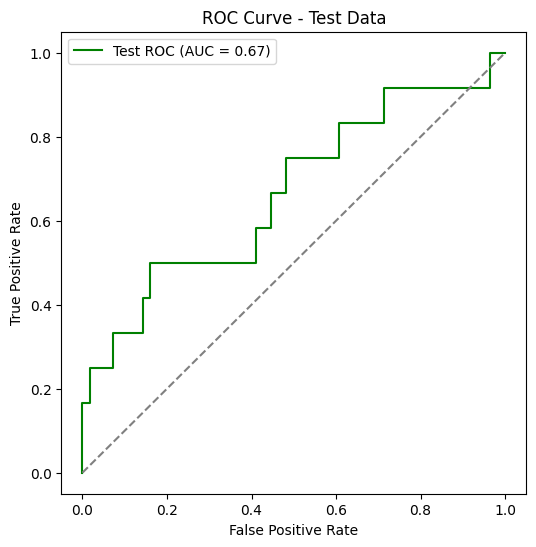

In [8]:
print("Evaluating on Test Data")

y_test_pred = best_model.predict(X_test)
if hasattr(best_model, "predict_proba"):
    y_scores_test = best_model.predict_proba(X_test)[:, 1]
elif hasattr(best_model, "decision_function"):
    y_scores_test = best_model.decision_function(X_test)
else:
    y_scores_test = y_test_pred

roc_auc_test = roc_auc_score(y_test, y_scores_test)
print(f"AUC-ROC (Test): {roc_auc_test:.4f}")

fpr, tpr, _ = roc_curve(y_test, y_scores_test)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"Test ROC (AUC = {roc_auc_test:.2f})", color="green")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Test Data")
plt.legend()
plt.show()

In [9]:
# print("Evaluating on Testing Data")

# y_test_pred = best_model.predict(X_test)
# if hasattr(best_model, "predict_proba"):
#     y_scores_test = best_model.predict_proba(X_test)[:, 1]
# elif hasattr(best_model, "decision_function"):
#     y_scores_test = best_model.decision_function(X_test)
# else:
#     y_scores_test = y_test_pred

# cm_test = confusion_matrix(y_test, y_test_pred)
# tn, fp, fn, tp = cm_test.ravel()

# precision = precision_score(y_test, y_test_pred)
# recall = recall_score(y_test, y_test_pred)
# roc_auc = roc_auc_score(y_test, y_scores_test)

# print(f"True Positives (TP): {tp}")
# print(f"False Positives (FP): {fp}")
# print(f"True Negatives (TN): {tn}")
# print(f"False Negatives (FN): {fn}")
# print(f"Precision: {precision:.3f}")
# print(f"Recall: {recall:.3f}")
# print(f"AUC-ROC: {roc_auc:.4f}")

# # ROC Curve
# fpr, tpr, _ = roc_curve(y_test, y_scores_test)
# plt.figure(figsize=(6, 6))
# plt.plot(fpr, tpr, label=f"Testing ROC (AUC = {roc_auc:.2f})", color="orange")
# plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
# plt.xlabel("False Positive Rate")
# plt.ylabel("True Positive Rate")
# plt.title("ROC Curve - Testing Data")
# plt.legend()
# plt.show()
